In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install opencv-python

In [ ]:
# computer vision
import cv2
from google.colab.patches import cv2_imshow
from imutils.object_detection import non_max_suppression
from skimage.metrics import structural_similarity as ssim


import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

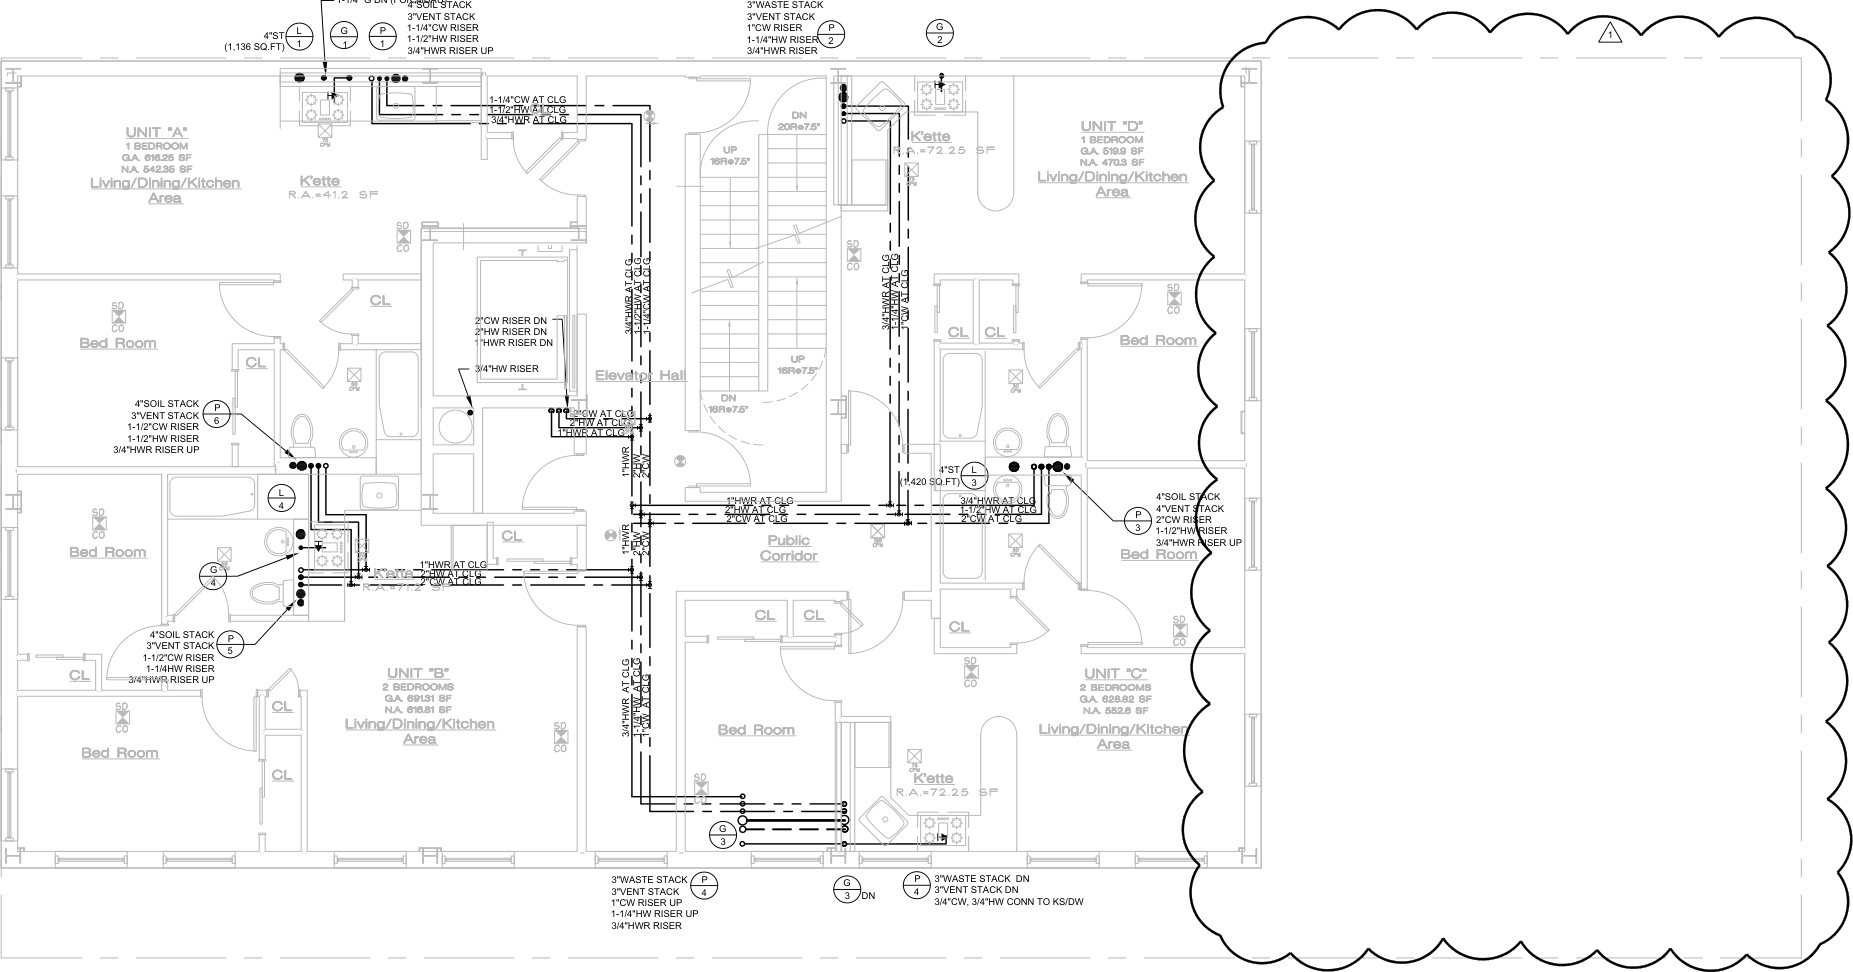

In [ ]:
# Load the image using OpenCV
img = cv2.imread("/content/drive/MyDrive/*Datasets/processed_data/page_64.png")

cv2_imshow(img)

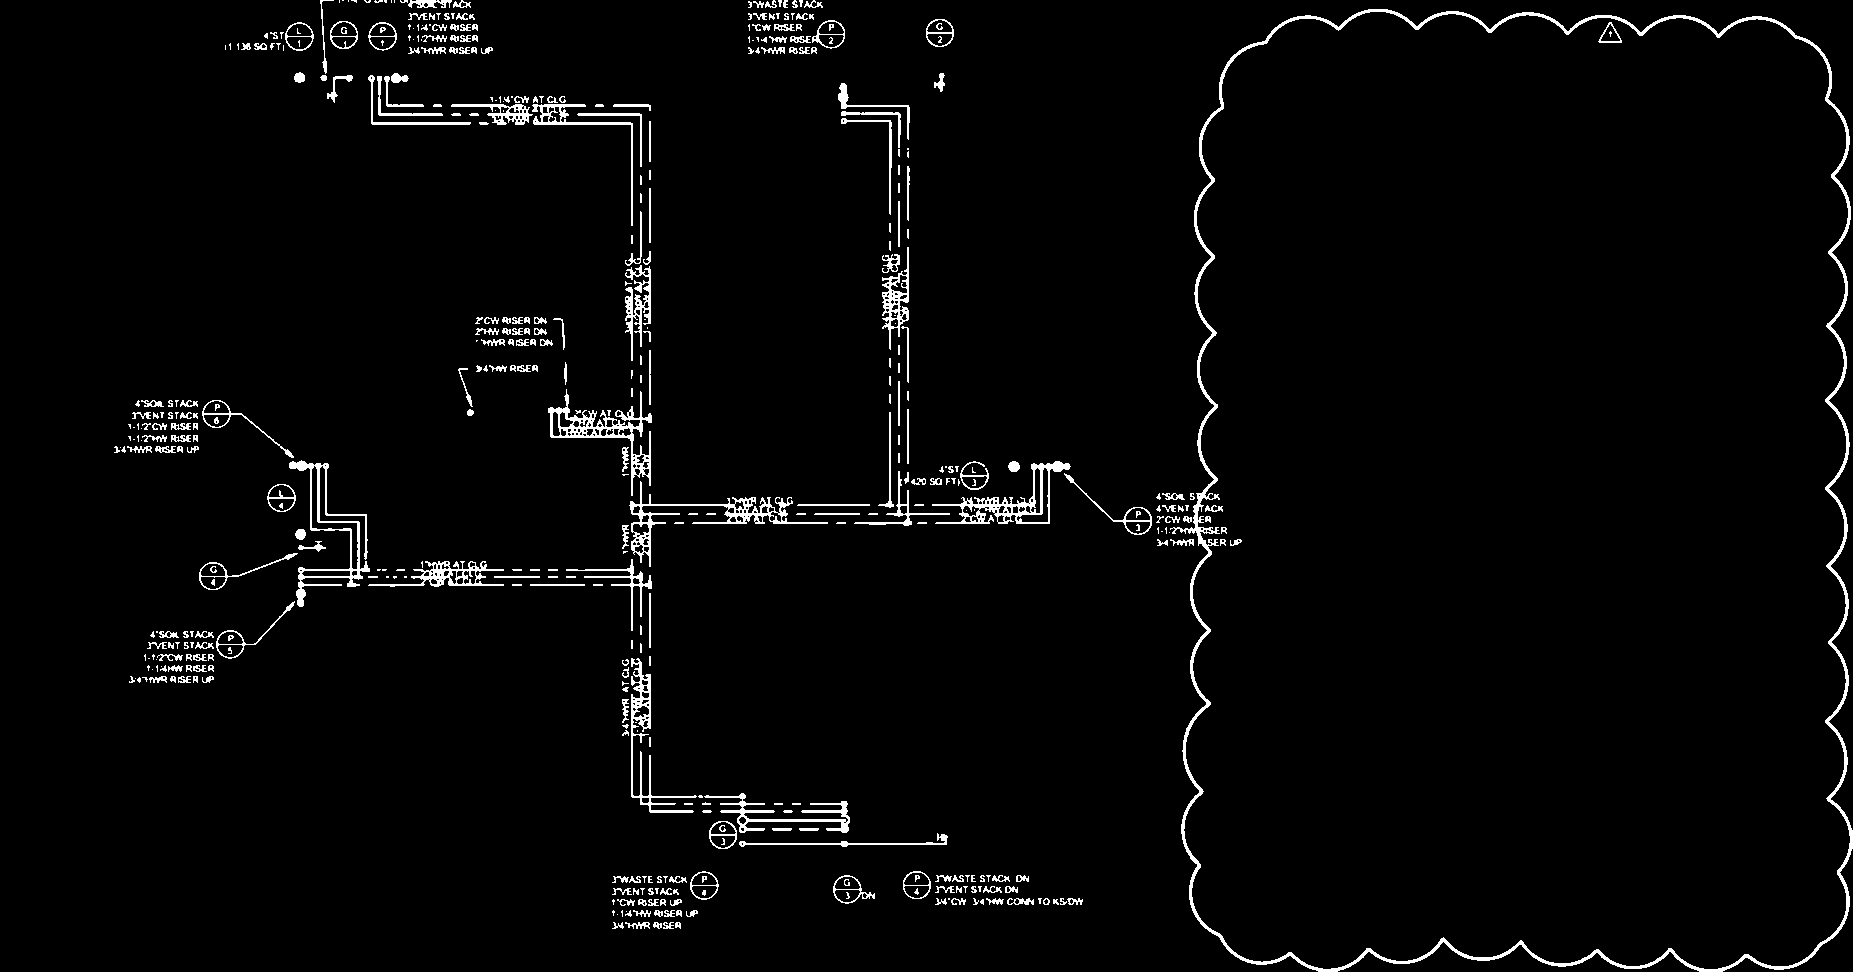

In [ ]:
# Preprocess the input image
def preprocess_image(img):
    if len(img.shape) == 3:  # Convert to grayscale if it's a color image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    eroded = cv2.erode(closed, kernel, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=1)
    return dilated

dilated = preprocess_image(img)
cv2_imshow(dilated)

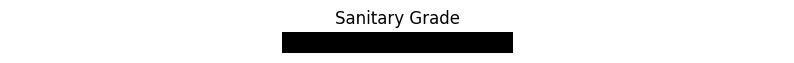

In [ ]:
def preprocess_template(template_img):
    # Convert to grayscale if it's a color image
    if len(template_img.shape) == 3:
        gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = template_img

    # Apply Gaussian blur to smooth the image
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, binary_img = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel_close = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel_close, iterations=3)
    kernel_erosion = np.ones((1, 1), np.uint8)
    eroded = cv2.erode(closed, kernel_erosion, iterations=1)
    final_img = eroded

    # Crop the image to remove whitespace
    coords = cv2.findNonZero(final_img)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped = final_img[y:y+h, x:x+w]
    else:
        cropped = final_img  # If no non-zero pixels are found, use the processed image

    return cropped

# Paths for templates
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Plumbing Legends/Sanitary Below Grade.png',
]

template_names = [
    'Sanitary Grade',
]

# Load and preprocess templates
templates = [preprocess_template(cv2.imread(path, 0)) for path in template_paths]

# Plot each template using matplotlib
plt.figure(figsize=(10, 5))
for i, (template, name) in enumerate(zip(templates, template_names)):
    plt.subplot(1, len(templates), i + 1)
    plt.imshow(template, cmap='gray')
    plt.title(name)
    plt.axis('off')
plt.show()

In [ ]:
# Define a function to preprocess templates and extract contours at specific 90-degree angles
def preprocess_template_with_all_contours(template_img, rotation_angles=[0, 90, 180, 270]):
    processed_templates = []
    for angle in rotation_angles:
        (h, w) = template_img.shape[:2]
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_template = cv2.warpAffine(template_img, M, (w, h))

        # Preprocess the rotated template
        gray = cv2.GaussianBlur(rotated_template, (3, 3), 0)
        _, binary_img = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
        kernel = np.ones((1, 1), np.uint8)
        processed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=1)
        processed = cv2.erode(processed, kernel, iterations=1)
        processed = cv2.dilate(processed, kernel, iterations=1)

        # Crop the image to remove whitespace
        coords = cv2.findNonZero(processed)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            cropped = processed[y:y+h, x:x+w]

            # Find all contours (both internal and external)
            contours, _ = cv2.findContours(cropped, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            if contours:
                # Combine all contours into one
                combined_contour = np.vstack(contours)
                processed_templates.append((cropped, combined_contour))  # Store template and its combined contour

    return processed_templates

# Function to count edges (vertices) of a contour
def count_contour_edges(contour, epsilon_factor=0.02):
    epsilon = epsilon_factor * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)
    return len(approx)

# Preprocess templates with rotations at 90-degree increments and extract all contours
all_template_variants = []
for t in templates:
    if t is not None:
        rotated_templates = preprocess_template_with_all_contours(t, rotation_angles=[0, 90, 180, 270])
        all_template_variants.append(rotated_templates)
    else:
        all_template_variants.append([])

# Define the scales and threshold for template matching
scales = [1.0, 0.95, 0.9, 0.85, 0.8]
threshold = 0.65

# Define template colors
template_colors = {
    'return_duct': (0, 0, 255),
    'supply_duct': (255, 0, 0),
    'ptac_legend': (255, 165, 0)
}

# Define template-specific thresholds
template_thresholds = {
    'return_duct': 0.7,
    'supply_duct': 0.5,
    'ptac_legend': 0.3
}

# Loop through each set of template variants
for template_variants, template_name in zip(all_template_variants, template_names):
    rects = []  # Store rectangles for strong matches
    match_info = []  # Store information about each strong match

    # Loop through each rotated variant of the template
    for scaled_template, template_contour in template_variants:
        for scale in scales:
            scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
            (h, w) = scaled_template_resized.shape[:2]

            # Extract contour from the resized template
            resized_contours, _ = cv2.findContours(scaled_template_resized, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            if not resized_contours:
                continue

            # Combine all resized contours into one
            resized_contour = np.vstack(resized_contours)

            # Count edges/vertices
            template_edges = count_contour_edges(template_contour)
            resized_edges = count_contour_edges(resized_contour)

            # Template matching
            result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
            (yCoords, xCoords) = np.where(result >= threshold)

            for (x, y) in zip(xCoords, yCoords):
                matched_region = dilated[y:y+h, x:x+w]
                if matched_region.shape == scaled_template_resized.shape:
                    # Perform contour-based similarity check
                    similarity_threshold = template_thresholds.get(template_name, 0.4)
                    similarity = cv2.matchShapes(template_contour, resized_contour, cv2.CONTOURS_MATCH_I1, 0)

                    # Combine similarity with edge count difference
                    edge_difference = abs(template_edges - resized_edges)
                    combined_score = similarity + (edge_difference * 0.1)  # Weighted combination

                    if combined_score < similarity_threshold:  # Use combined score for matching
                        rects.append((x, y, x + w, y + h))
                        match_info.append({
                            "point": (x, y),
                            "scale": scale,
                            "size": (w, h),
                            "score": combined_score,
                            "edge_difference": edge_difference
                        })

    # Apply non-maxima suppression with an overlap threshold to reduce duplicates
    rects_np = np.array(rects)
    pick = non_max_suppression(rects_np, overlapThresh=0.3)  # Adjust overlap threshold as needed

    # Draw the final matches and print details
    color = template_colors.get(template_name, (0, 255, 0))
    if len(pick) > 0:
        print(f"Matches for template: {template_name}")
        for i, (startX, startY, endX, endY) in enumerate(pick):
            # Draw rectangle
            cv2.rectangle(img, (startX, startY), (endX, endY), color, 2)
            cv2.putText(img, template_name, (startX, startY - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

            # Print match details
            match = match_info[i]
            print(f"  Match {i + 1}:")
            print(f"    Position: {match['point']}")
            print(f"    Size: {match['size']}")
            print(f"    Scale: {match['scale']}")
            print(f"    Combined Score: {match['score']}")
            print(f"    Edge Difference: {match['edge_difference']}")
    else:
        print(f"No matches found for template: {template_name}")

# Display the final image with detected features
cv2_imshow(img)